# Proyek Analisis Data: Bike Sharing Dataset 🚲

**Nama:** Hamara Talia  
**ID Dicoding:** CDCC889D6X0678


## Menentukan Pertanyaan Bisnis

1. **Bagaimana tren penyewaan sepeda (Month-over-Month) sepanjang tahun 2012 dibandingkan dengan tahun 2011?**

2. **Pada jam berapa penyewaan sepeda mencapai puncaknya di hari kerja (workingday) dibandingkan dengan hari libur (holiday) selama periode 2011-2012?**  


## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, shapiro

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.dpi'] = 100
print("Library berhasil diimpor.")

Library berhasil diimpor.


## Data Wrangling
### Gathering Data

In [ ]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

print(f"day_df shape: {day_df.shape}")
print(f"hour_df shape: {hour_df.shape}")
day_df.head()

day_df shape: (731, 16)
hour_df shape: (17379, 17)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Assessing Data

In [ ]:
# Assessing day_df
print("=== day_df Info ===")
print(day_df.info())
print("\nMissing Values:\n", day_df.isnull().sum())
print("\nDuplicates:", day_df.duplicated().sum())

=== day_df Info ===
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB
None

Missing Values:
 instant       0
dteday        0
season        0
yr            0
m

In [ ]:
# Assessing hour_df
print("=== hour_df Info ===")
print(hour_df.info())
print("\nMissing Values:\n", hour_df.isnull().sum())
print("\nDuplicates:", hour_df.duplicated().sum())

=== hour_df Info ===
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB
None

Missing Values:
 instant       0
dted

**Insight:** Kualitas dataset sangat baik — tidak ditemukan missing value maupun duplikasi. 
Kolom `dteday` perlu dikonversi ke tipe datetime, dan kolom `yr` perlu di-mapping agar lebih intuitif.

### Cleaning Data

In [ ]:
# Konversi tipe data dan mapping
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
day_df['yr'] = day_df['yr'].map({0: 2011, 1: 2012})
hour_df['yr'] = hour_df['yr'].map({0: 2011, 1: 2012})

# Label mapping untuk keterbacaan
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Rain', 4: 'Heavy Rain'}
day_df['season_label'] = day_df['season'].map(season_map)
hour_df['season_label'] = hour_df['season'].map(season_map)
day_df['weather_label'] = day_df['weathersit'].map(weather_map)
hour_df['weather_label'] = hour_df['weathersit'].map(weather_map)

# Teknik Lanjutan: Binning jam menjadi kategori waktu
def categorize_time(hour):
    if 5 <= hour <= 10: return 'Pagi'
    elif 11 <= hour <= 14: return 'Siang'
    elif 15 <= hour <= 18: return 'Sore'
    else: return 'Malam'

hour_df['time_category'] = hour_df['hr'].apply(categorize_time)
print("Data cleaning selesai!")
day_df[['dteday', 'yr', 'season_label', 'weather_label']].head()

Data cleaning selesai!


,dteday,yr,season_label,weather_label
0,2011-01-01,2011,Spring,Mist
1,2011-01-02,2011,Spring,Mist
2,2011-01-03,2011,Spring,Clear
3,2011-01-04,2011,Spring,Clear
4,2011-01-05,2011,Spring,Clear


## Exploratory Data Analysis (EDA)

### EDA Numerikal: Statistik Deskriptif

In [ ]:
# Detailed Descriptive Statistics
num_cols = ['cnt', 'casual', 'registered', 'temp', 'hum', 'windspeed']
print("=== Descriptive Statistics (day_df) ===")
day_df[num_cols].describe()

=== Descriptive Statistics (day_df) ===


,cnt,casual,registered,temp,hum,windspeed
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,4504.348837,848.176471,3656.172367,0.495385,0.627894,0.190486
std,1937.211452,686.622488,1560.256377,0.183051,0.142429,0.077498
min,22.000000,2.000000,20.000000,0.059130,0.000000,0.022392
25%,3152.000000,315.500000,2497.000000,0.337083,0.520000,0.134950
50%,4548.000000,713.000000,3662.000000,0.498333,0.626667,0.180975
75%,5956.000000,1096.000000,4776.500000,0.655417,0.730209,0.233214
max,8714.000000,3410.000000,6946.000000,0.861667,0.972500,0.507463


In [ ]:
# Percentile Analysis (5th, 10th, 25th, 50th, 75th, 90th, 95th)
percentiles = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
print("=== Percentile Analysis ===")
day_df[num_cols].quantile(percentiles).round(2)

=== Percentile Analysis ===


,cnt,casual,registered,temp,hum,windspeed
0.05,1331.0,88.0,1177.5,0.21,0.41,0.08
0.10,1746.0,139.0,1506.0,0.26,0.45,0.10
0.25,3152.0,315.5,2497.0,0.34,0.52,0.13
0.50,4548.0,713.0,3662.0,0.50,0.63,0.18
0.75,5956.0,1096.0,4776.5,0.66,0.73,0.23
0.90,7290.0,1869.0,5893.0,0.73,0.82,0.30
0.95,7576.0,2355.0,6280.5,0.77,0.87,0.34


In [ ]:
# Variance & Std Dev per bulan
print("=== Variance & Std Dev penyewaan per Bulan ===")
monthly_stats = day_df.groupby(['yr', 'mnth'])['cnt'].agg(['mean', 'std', 'var']).round(2)
print(monthly_stats.to_string())

=== Variance & Std Dev penyewaan per Bulan ===
              mean      std         var
yr   mnth                              
2011 1     1231.90   372.43   138706.09
     2     1721.96   398.51   158809.29
     3     2065.97   550.97   303569.83
     4     3162.33  1042.09  1085959.06
     5     4381.32   572.93   328246.36
     6     4783.73   444.45   197533.86
     7     4559.39   680.09   462523.45
     8     4409.39   809.85   655860.91
     9     4247.27   965.38   931953.24
     10    3984.23  1103.48  1217672.18
     11    3405.57   788.25   621336.94
     12    2816.87   958.76   919226.85
2012 1     3120.77   872.85   761870.85
     2     3556.45   870.72   758161.40
     3     5318.55  1251.16  1565408.06
     4     5807.47  1308.94  1713321.09
     5     6318.23  1078.40  1162955.18
     6     6761.00   954.20   910507.17
     7     6567.97   867.18   752007.63
     8     6919.45   794.06   630529.72
     9     7285.77   979.16   958756.12
     10    6414.23  1941.82  3770

In [ ]:
# Skewness & Kurtosis Analysis
print("=== Skewness & Kurtosis ===")
for col in num_cols:
    sk = day_df[col].skew()
    ku = day_df[col].kurtosis()
    print(f"{col:>12}: Skewness={sk:.3f}, Kurtosis={ku:.3f}")

=== Skewness & Kurtosis ===
         cnt: Skewness=-0.047, Kurtosis=-0.812
      casual: Skewness=1.266, Kurtosis=1.322
  registered: Skewness=0.044, Kurtosis=-0.713
        temp: Skewness=-0.055, Kurtosis=-1.119
         hum: Skewness=-0.070, Kurtosis=-0.065
   windspeed: Skewness=0.677, Kurtosis=0.411


### EDA Univariate: Distribusi Variabel Numerik

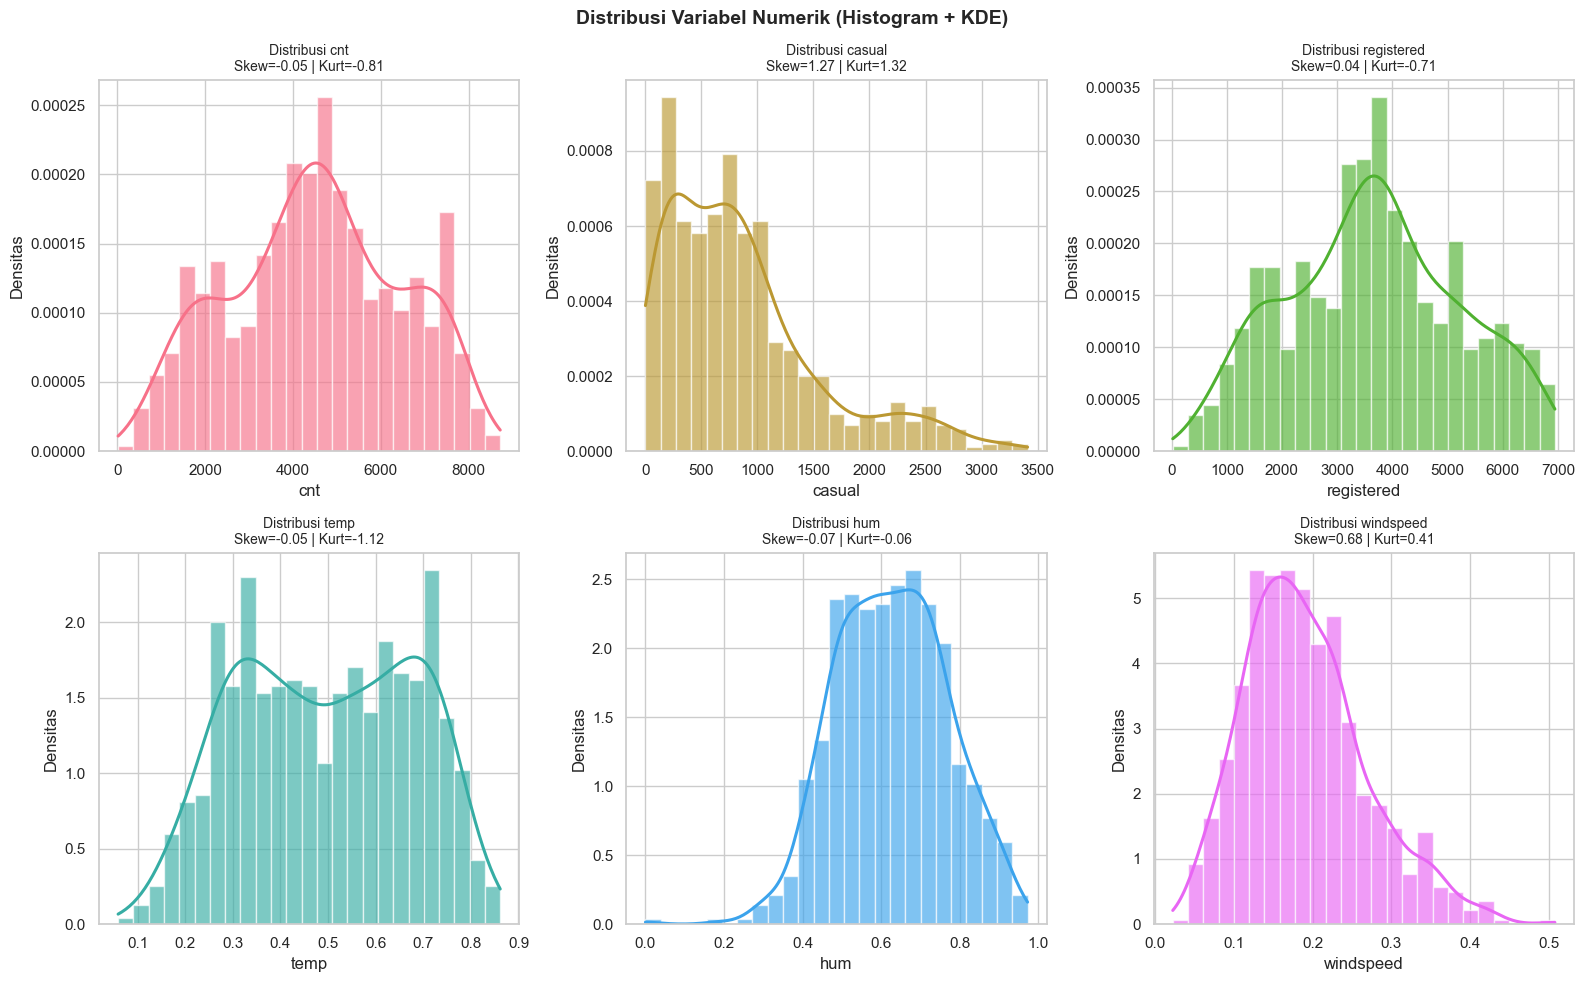

In [ ]:
# Histogram + KDE untuk semua variabel numerik
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribusi Variabel Numerik (Histogram + KDE)", fontsize=14, fontweight='bold')
colors = sns.color_palette("husl", 6)

for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    data = day_df[col]
    ax.hist(data, bins=25, color=colors[i], alpha=0.65, edgecolor='white', density=True)
    kde_x = np.linspace(data.min(), data.max(), 200)
    kde = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color=colors[i], linewidth=2.2)
    ax.set_title(f"Distribusi {col}\nSkew={data.skew():.2f} | Kurt={data.kurtosis():.2f}", fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel("Densitas")

plt.tight_layout()
plt.show()

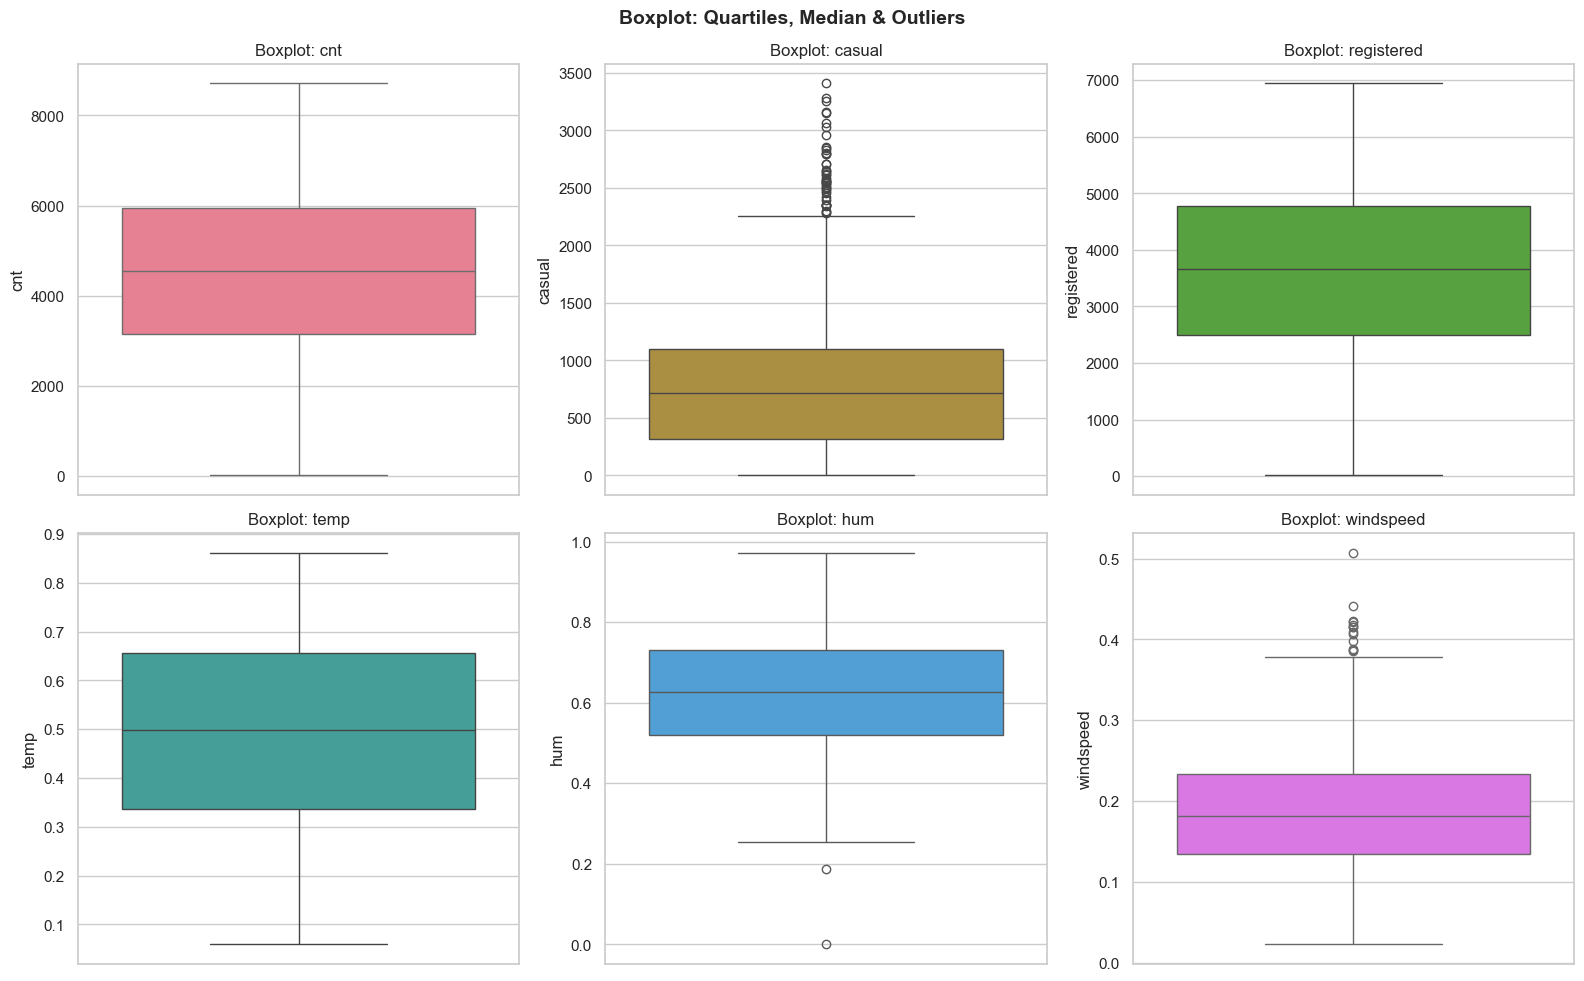

In [ ]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Boxplot: Quartiles, Median & Outliers", fontsize=14, fontweight='bold')
for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    sns.boxplot(y=day_df[col], ax=ax, color=colors[i])
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

=== Shapiro-Wilk Test Results ===
           cnt: stat=0.9191, p=0.000000 → Non-Normal (p<=0.05)
        casual: stat=0.8663, p=0.000000 → Non-Normal (p<=0.05)
    registered: stat=0.9322, p=0.000000 → Non-Normal (p<=0.05)
          temp: stat=0.9407, p=0.000000 → Non-Normal (p<=0.05)
           hum: stat=0.9857, p=0.040680 → Non-Normal (p<=0.05)
     windspeed: stat=0.9752, p=0.001291 → Non-Normal (p<=0.05)


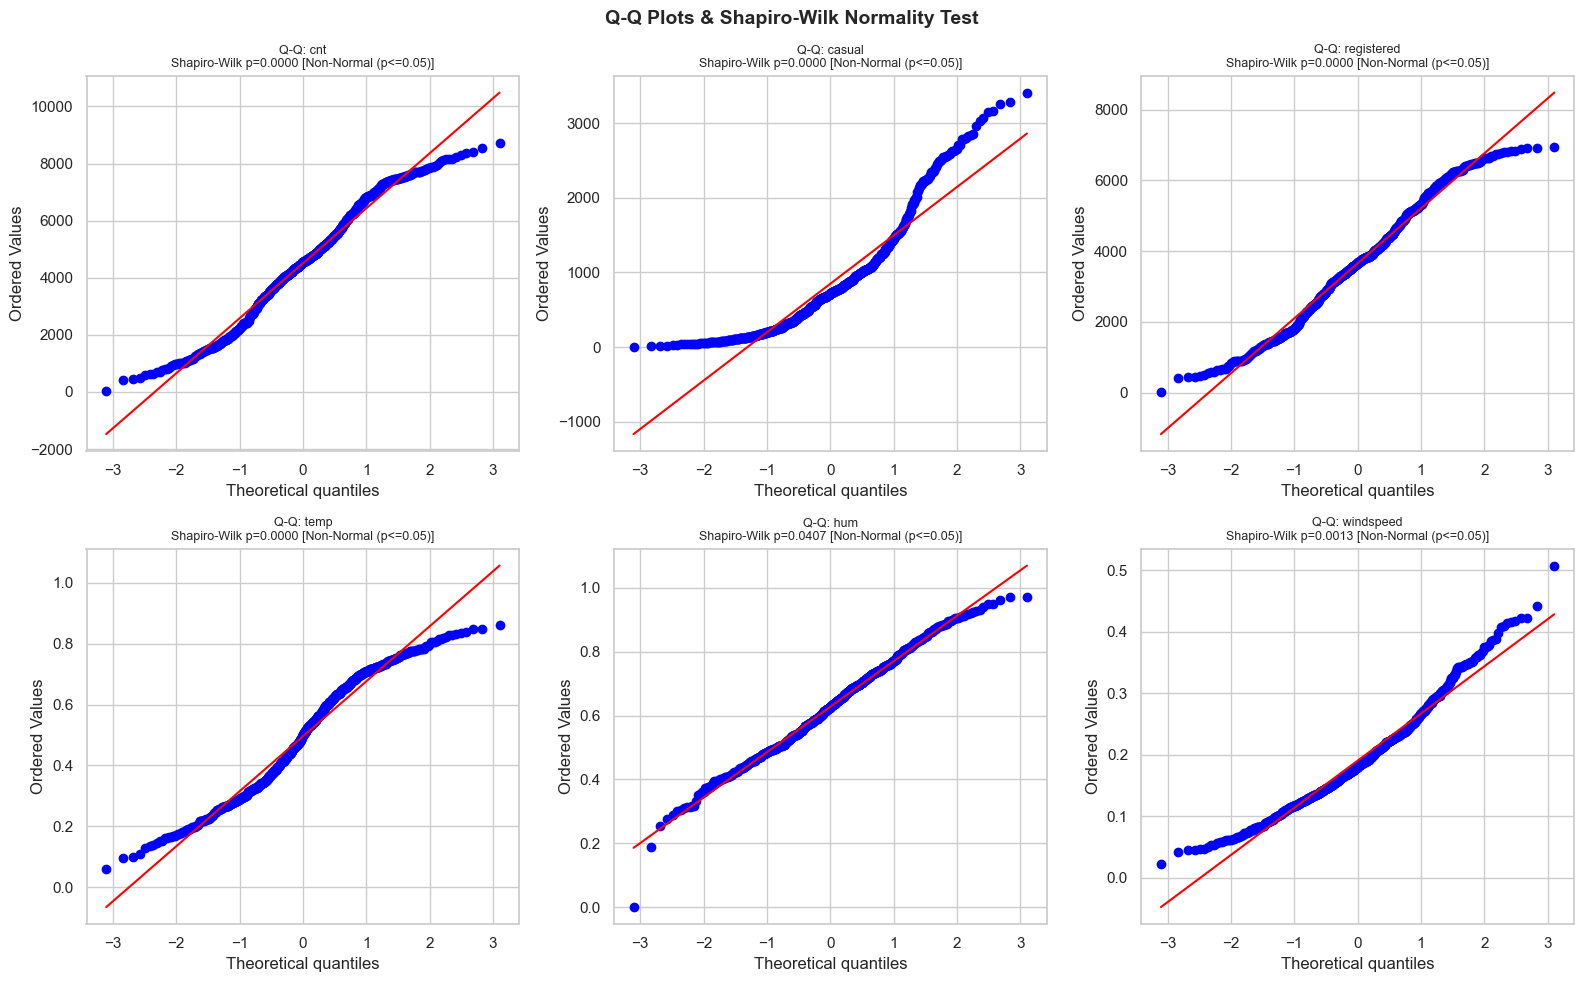

In [ ]:
# Q-Q Plot + Shapiro-Wilk Normality Test
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Q-Q Plots & Shapiro-Wilk Normality Test", fontsize=14, fontweight='bold')
print("=== Shapiro-Wilk Test Results ===")
for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    data = day_df[col].dropna()
    stats.probplot(data, dist="norm", plot=ax)
    sw_data = data[:200] if len(data) > 200 else data
    stat, p = shapiro(sw_data)
    result = 'Normal (p>0.05)' if p > 0.05 else 'Non-Normal (p<=0.05)'
    ax.set_title(f"Q-Q: {col}\nShapiro-Wilk p={p:.4f} [{result}]", fontsize=9)
    print(f"  {col:>12}: stat={stat:.4f}, p={p:.6f} → {result}")
plt.tight_layout()
plt.show()

### EDA Kategorikal: Frekuensi & Distribusi

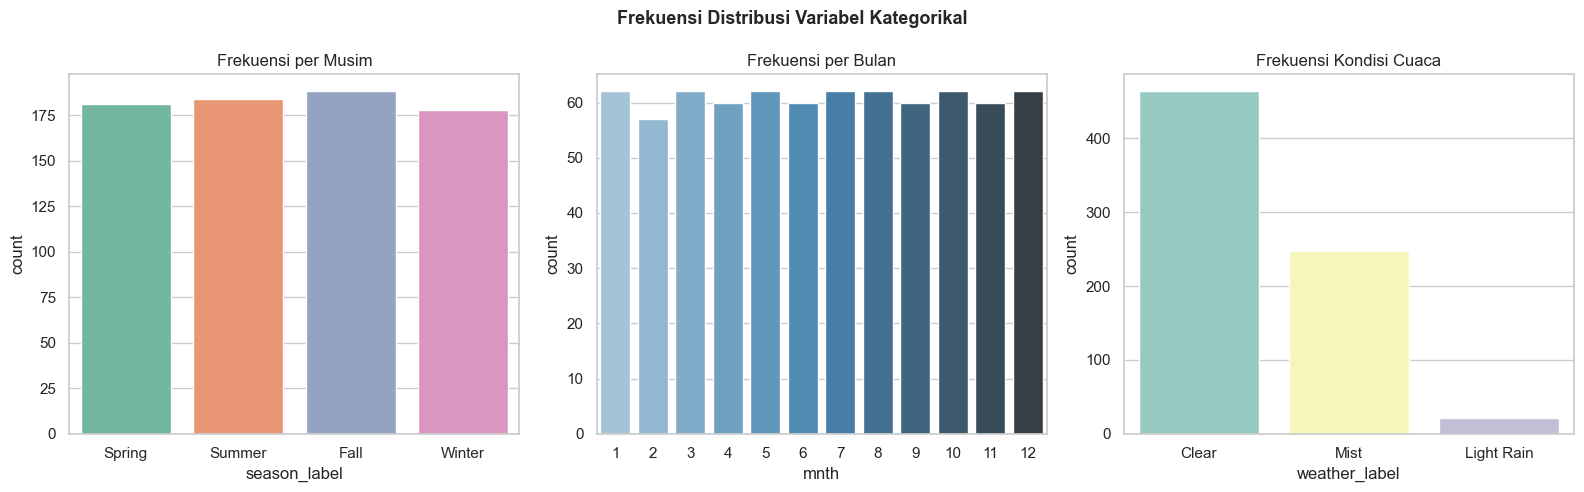

In [ ]:
# Countplot untuk variabel kategorikal
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Frekuensi Distribusi Variabel Kategorikal", fontsize=13, fontweight='bold')

sns.countplot(data=day_df, x='season_label', ax=axes[0], palette='Set2',
              order=['Spring', 'Summer', 'Fall', 'Winter'])
axes[0].set_title("Frekuensi per Musim")

sns.countplot(data=day_df, x='mnth', ax=axes[1], palette='Blues_d')
axes[1].set_title("Frekuensi per Bulan")

sns.countplot(data=day_df, x='weather_label', ax=axes[2], palette='Set3',
              order=['Clear', 'Mist', 'Light Rain'])
axes[2].set_title("Frekuensi Kondisi Cuaca")

plt.tight_layout()
plt.show()

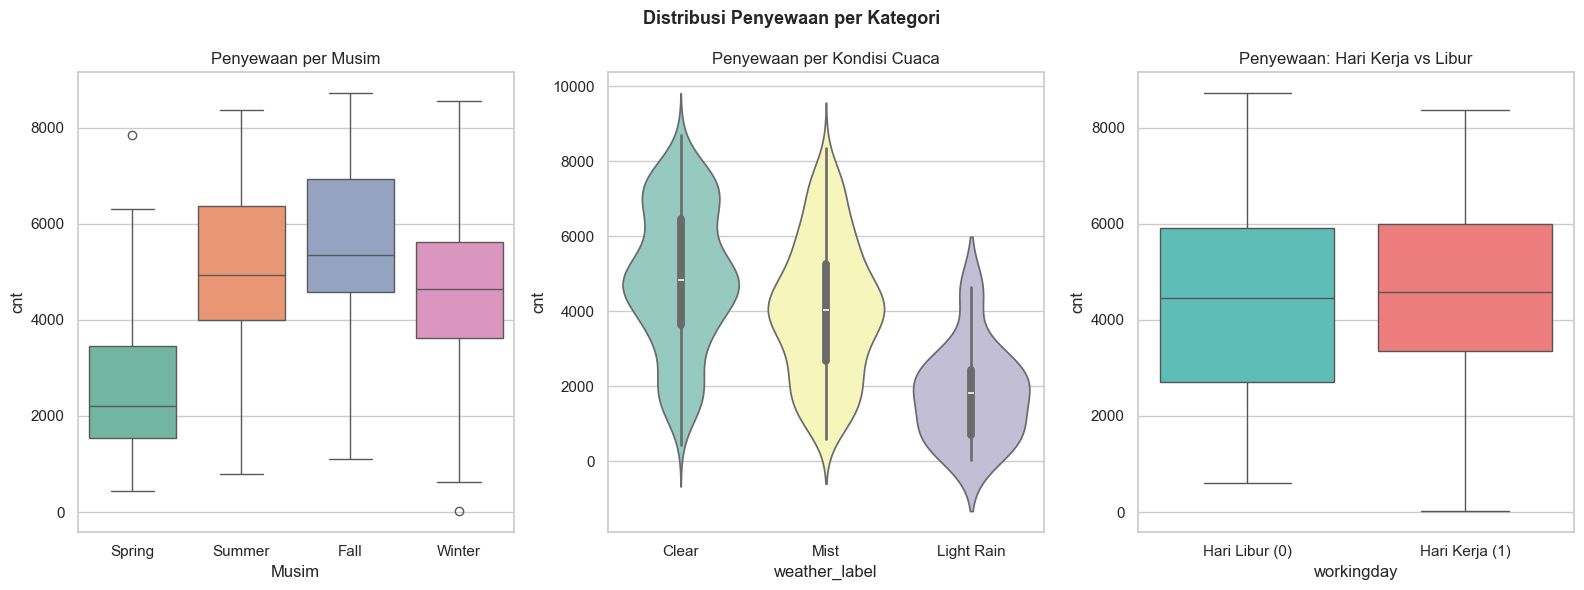

In [ ]:
# Box Plot & Violin Plot per kategori
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Distribusi Penyewaan per Kategori", fontsize=13, fontweight='bold')

sns.boxplot(data=day_df, x='season_label', y='cnt', ax=axes[0], palette='Set2',
            order=['Spring', 'Summer', 'Fall', 'Winter'])
axes[0].set_title("Penyewaan per Musim")
axes[0].set_xlabel("Musim")

sns.violinplot(data=day_df, x='weather_label', y='cnt', ax=axes[1], palette='Set3',
               order=['Clear', 'Mist', 'Light Rain'])
axes[1].set_title("Penyewaan per Kondisi Cuaca")

sns.boxplot(data=day_df, x='workingday', y='cnt', ax=axes[2],
            palette=['#4ECDC4', '#FF6B6B'])
axes[2].set_xticklabels(['Hari Libur (0)', 'Hari Kerja (1)'])
axes[2].set_title("Penyewaan: Hari Kerja vs Libur")

plt.tight_layout()
plt.show()

In [ ]:
# ANOVA Statistical Testing
print("=== ANOVA Test: Signifikansi Perbedaan Antar Kelompok ===\n")

# Season
groups_s = [day_df[day_df['season'] == s]['cnt'].values for s in [1, 2, 3, 4]]
f1, p1 = f_oneway(*groups_s)
print(f"[Musim]          F={f1:.4f}, p={p1:.6f} → {'SIGNIFIKAN ✅' if p1 < 0.05 else 'Tidak Signifikan'}")

# Weather
groups_w = [day_df[day_df['weathersit'] == w]['cnt'].values for w in [1, 2, 3]]
f2, p2 = f_oneway(*groups_w)
print(f"[Cuaca]          F={f2:.4f}, p={p2:.6f} → {'SIGNIFIKAN ✅' if p2 < 0.05 else 'Tidak Signifikan'}")

# Workingday
g1 = day_df[day_df['workingday'] == 1]['cnt'].values
g0 = day_df[day_df['workingday'] == 0]['cnt'].values
f3, p3 = f_oneway(g1, g0)
print(f"[Hari Kerja/Libur] F={f3:.4f}, p={p3:.6f} → {'SIGNIFIKAN ✅' if p3 < 0.05 else 'Tidak Signifikan ❌'}")
print("\nα = 0.05")

=== ANOVA Test: Signifikansi Perbedaan Antar Kelompok ===

[Musim]          F=128.7696, p=0.000000 → SIGNIFIKAN ✅
[Cuaca]          F=40.0660, p=0.000000 → SIGNIFIKAN ✅
[Hari Kerja/Libur] F=2.7367, p=0.098495 → Tidak Signifikan ❌

α = 0.05


### EDA Multivariate: Korelasi & Hubungan Antar Variabel

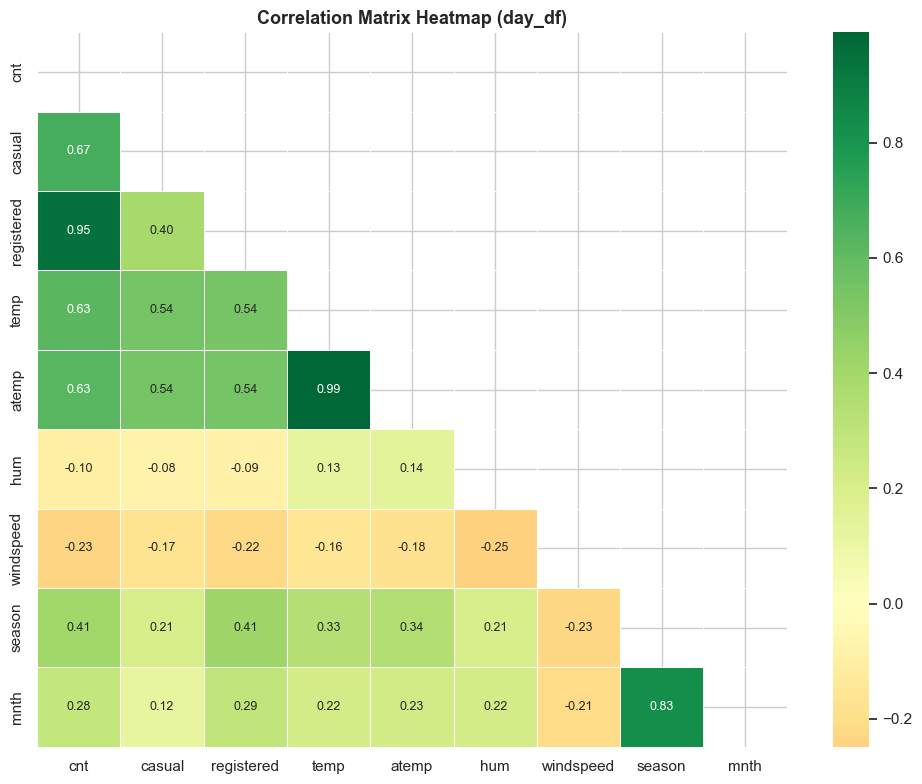

In [ ]:
# Correlation Matrix Heatmap
corr_cols = ['cnt', 'casual', 'registered', 'temp', 'atemp', 'hum', 'windspeed', 'season', 'mnth']
corr_matrix = day_df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdYlGn',
            mask=mask, center=0, ax=ax, linewidths=0.5, annot_kws={"size": 9})
ax.set_title("Correlation Matrix Heatmap (day_df)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

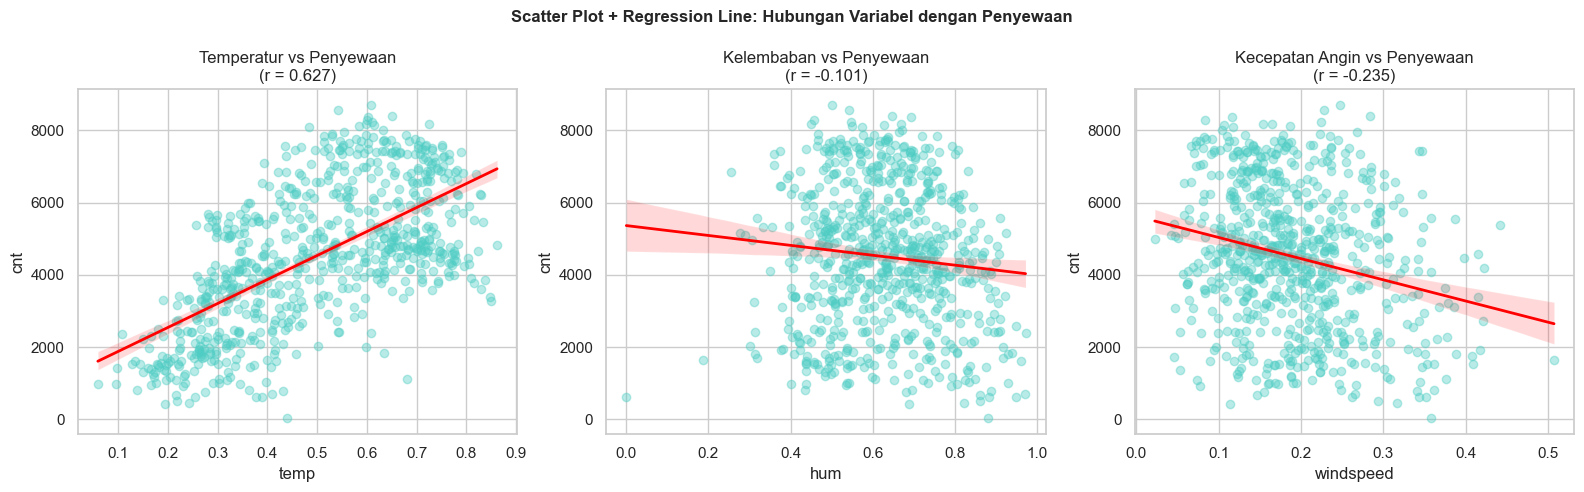

In [ ]:
# Scatter Plot + Regression Line
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Scatter Plot + Regression Line: Hubungan Variabel dengan Penyewaan",
             fontsize=12, fontweight='bold')

pairs = [('temp','cnt','Temperatur vs Penyewaan'),
         ('hum','cnt','Kelembaban vs Penyewaan'),
         ('windspeed','cnt','Kecepatan Angin vs Penyewaan')]

for i, (x, y, title) in enumerate(pairs):
    r = day_df[[x,y]].corr().iloc[0,1]
    sns.regplot(data=day_df, x=x, y=y, ax=axes[i],
                scatter_kws={'alpha':0.4, 'color':'#4ECDC4'},
                line_kws={'color':'red', 'linewidth':2})
    axes[i].set_title(f"{title}\n(r = {r:.3f})")

plt.tight_layout()
plt.show()

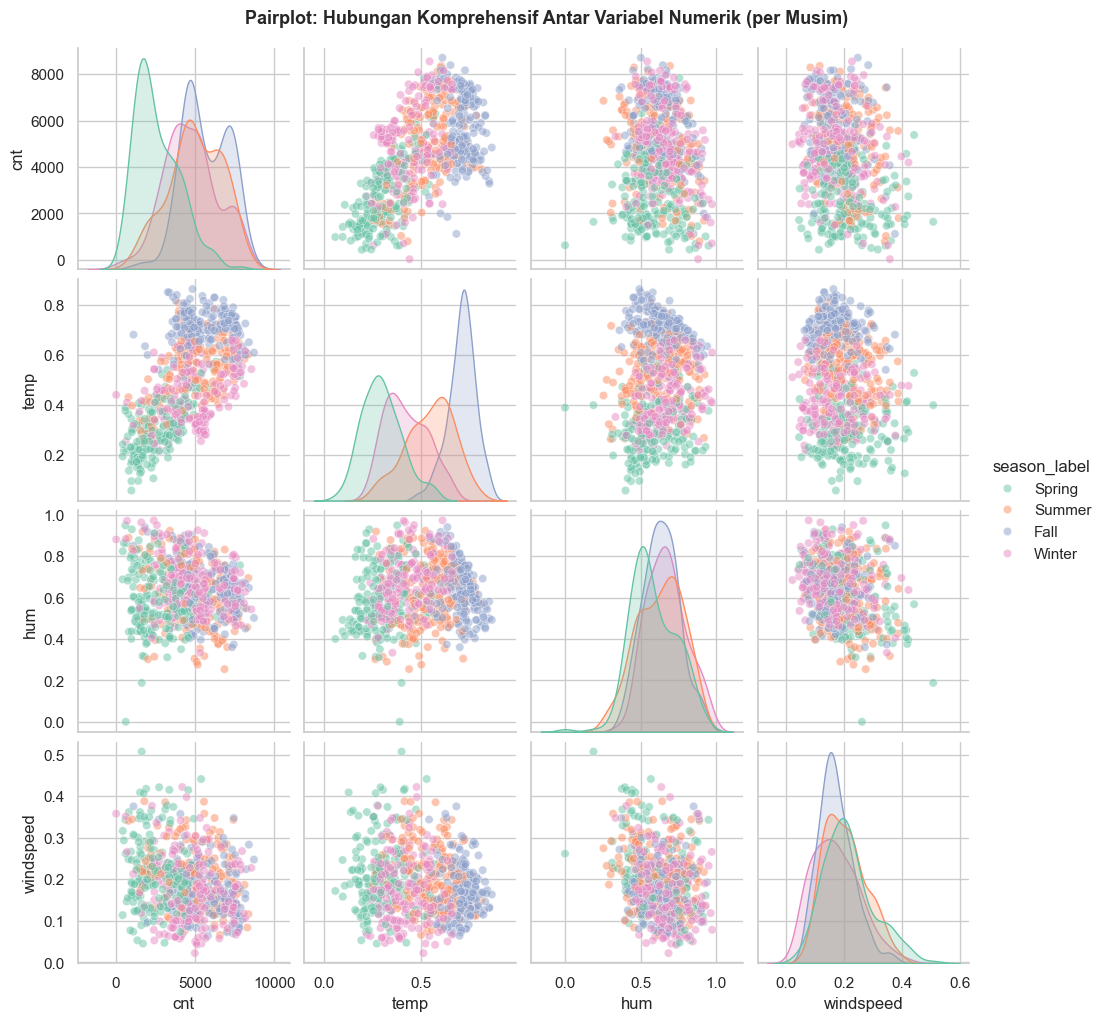

In [ ]:
# Pairplot
pairplot_cols = ['cnt', 'temp', 'hum', 'windspeed', 'season_label']
g = sns.pairplot(day_df[pairplot_cols], hue='season_label',
                 hue_order=['Spring','Summer','Fall','Winter'],
                 plot_kws={'alpha': 0.5}, diag_kind='kde',
                 palette='Set2', height=2.5)
g.fig.suptitle("Pairplot: Hubungan Komprehensif Antar Variabel Numerik (per Musim)",
               y=1.02, fontsize=13, fontweight='bold')
plt.show()

## Visualization & Explanatory Analysis
### Pertanyaan 1: Tren Bulanan 2011 vs 2012

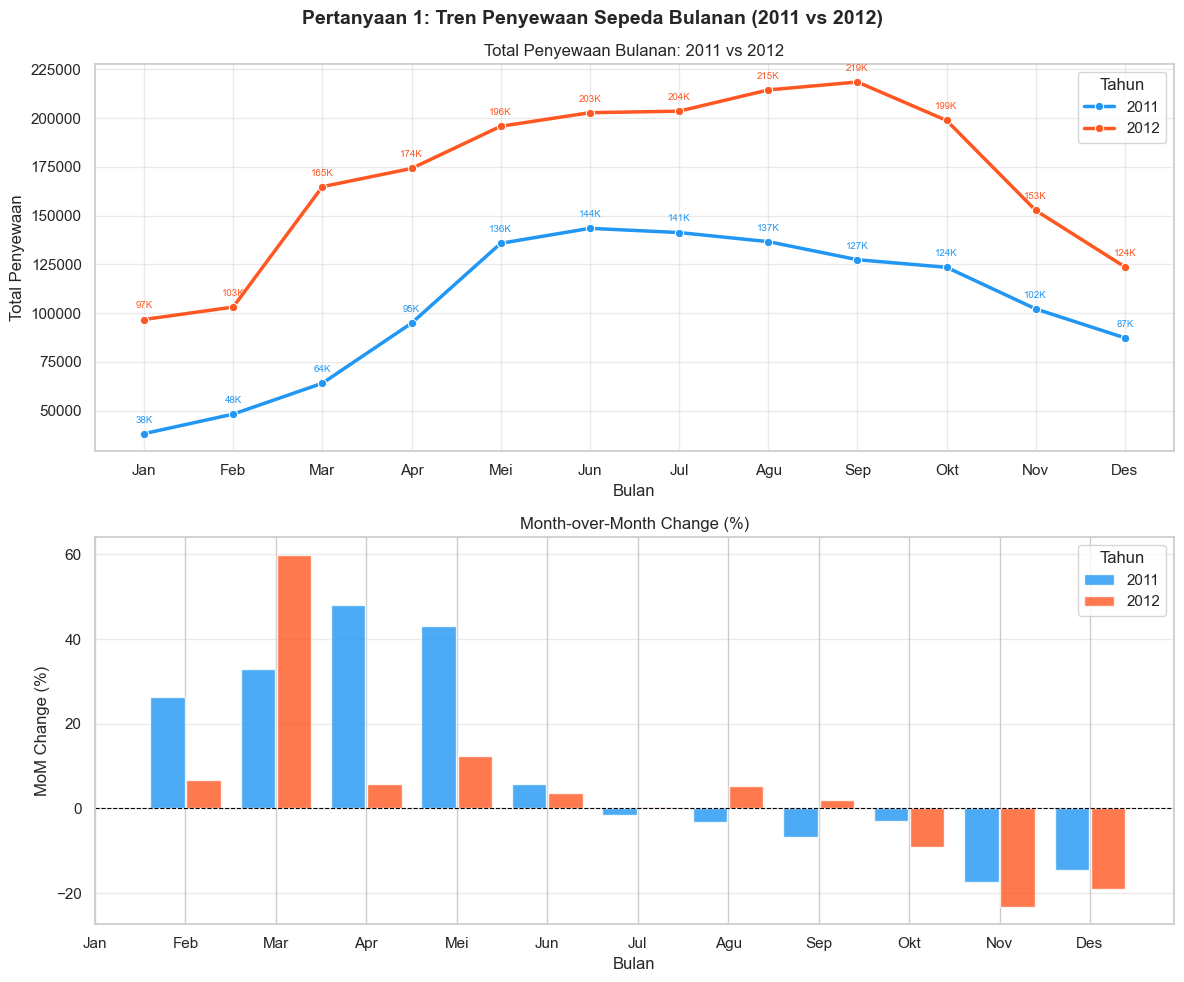

In [ ]:
monthly_trend = day_df.groupby(['yr', 'mnth'])['cnt'].sum().reset_index()
monthly_trend['mom_change'] = monthly_trend.groupby('yr')['cnt'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle("Pertanyaan 1: Tren Penyewaan Sepeda Bulanan (2011 vs 2012)", fontsize=14, fontweight='bold')

sns.lineplot(data=monthly_trend, x='mnth', y='cnt', hue='yr', marker='o',
             palette={2011: '#2196F3', 2012: '#FF5722'}, ax=axes[0], linewidth=2.5)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
axes[0].set_xlabel("Bulan")
axes[0].set_ylabel("Total Penyewaan")
axes[0].set_title("Total Penyewaan Bulanan: 2011 vs 2012")
axes[0].grid(True, alpha=0.4)
axes[0].legend(title="Tahun")

for yr, color in [(2011, '#2196F3'), (2012, '#FF5722')]:
    subset = monthly_trend[monthly_trend['yr'] == yr]
    for _, row in subset.iterrows():
        axes[0].annotate(f"{row['cnt']/1000:.0f}K", (row['mnth'], row['cnt']),
                         textcoords="offset points", xytext=(0, 8),
                         ha='center', fontsize=7, color=color)

for yr, color in [(2011, '#2196F3'), (2012, '#FF5722')]:
    subset = monthly_trend[monthly_trend['yr'] == yr].dropna(subset=['mom_change'])
    axes[1].bar(subset['mnth'] + (0.2 if yr == 2012 else -0.2), subset['mom_change'],
                width=0.38, color=color, alpha=0.8, label=str(yr))
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
axes[1].set_xlabel("Bulan")
axes[1].set_ylabel("MoM Change (%)")
axes[1].set_title("Month-over-Month Change (%)")
axes[1].legend(title="Tahun")
axes[1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

**Insight Pertanyaan 1:**  
Grafik tren bulanan secara jelas memperlihatkan bahwa volume penyewaan di tahun 2012 jauh lebih tinggi 
dibanding tahun 2011 di setiap bulannya, dengan pola musiman yang konsisten memuncak pada pertengahan 
tahun (bulan ke-6 hingga ke-9). Grafik MoM Change menunjukkan fluktuasi yang serupa di kedua tahun, 
dengan lonjakan positif saat musim semi dan penurunan di penghujung tahun.

### Pertanyaan 2: Jam Puncak Hari Kerja vs Libur (2011-2012)

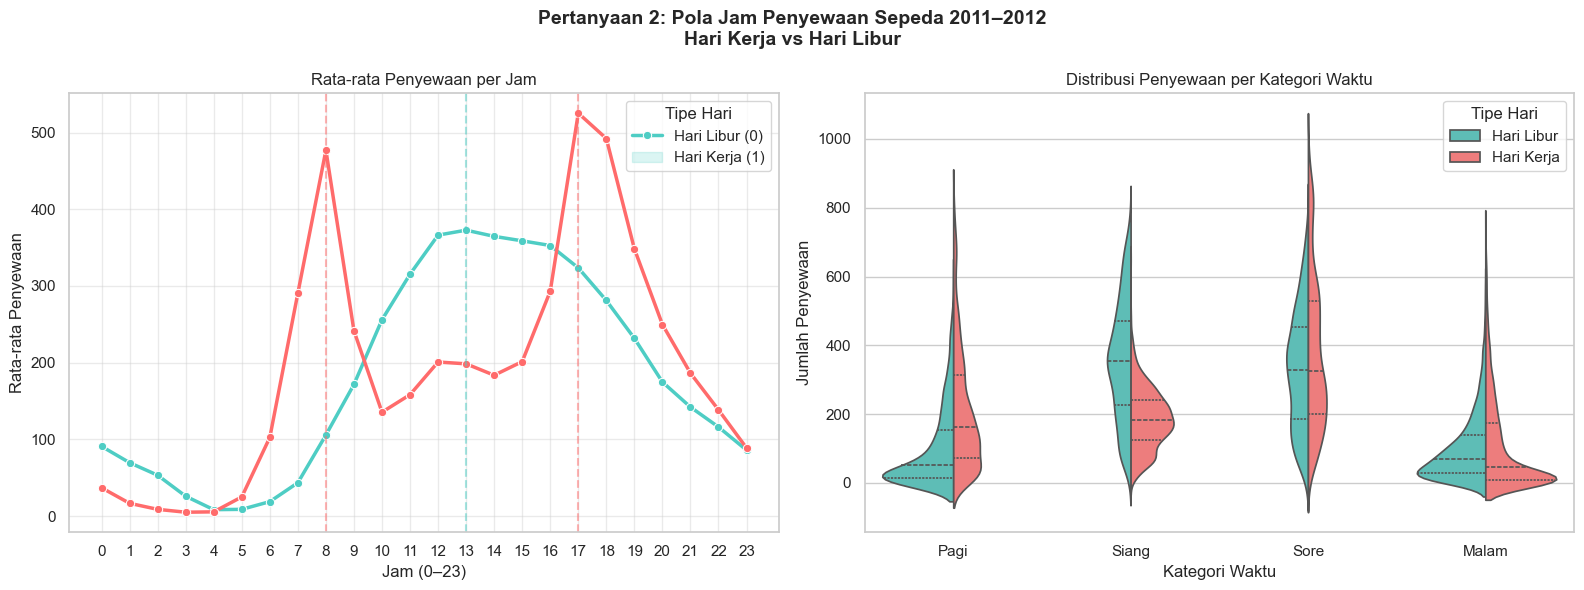

In [ ]:
hourly_workday = hour_df.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Pertanyaan 2: Pola Jam Penyewaan Sepeda 2011–2012\nHari Kerja vs Hari Libur",
             fontsize=14, fontweight='bold')

sns.lineplot(data=hourly_workday, x='hr', y='cnt', hue='workingday',
             palette={0: '#4ECDC4', 1: '#FF6B6B'}, marker='o', ax=axes[0], linewidth=2.5)
axes[0].set_xticks(range(0, 24))
axes[0].set_xlabel("Jam (0–23)")
axes[0].set_ylabel("Rata-rata Penyewaan")
axes[0].set_title("Rata-rata Penyewaan per Jam")
axes[0].legend(title="Tipe Hari", labels=['Hari Libur (0)', 'Hari Kerja (1)'])
axes[0].axvline(8, color='#FF6B6B', linestyle='--', alpha=0.5)
axes[0].axvline(17, color='#FF6B6B', linestyle='--', alpha=0.5)
axes[0].axvline(13, color='#4ECDC4', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.4)

# Violin plot per kategori waktu
hour_df['Tipe Hari'] = hour_df['workingday'].map({0: 'Hari Libur', 1: 'Hari Kerja'})
sns.violinplot(data=hour_df, x='time_category', y='cnt', hue='Tipe Hari',
               order=['Pagi', 'Siang', 'Sore', 'Malam'],
               palette=['#4ECDC4', '#FF6B6B'], split=True, ax=axes[1], inner='quartile')
axes[1].set_title("Distribusi Penyewaan per Kategori Waktu")
axes[1].set_xlabel("Kategori Waktu")
axes[1].set_ylabel("Jumlah Penyewaan")

plt.tight_layout()
plt.show()

**Insight Pertanyaan 2:**  
Grafik pola jam penyewaan menunjukkan divergensi perilaku yang ekstrem:
- **Hari Kerja:** Dua puncak tajam (bimodal) pada jam **08:00** dan **17:00** mencerminkan penggunaan sebagai transportasi komuter.
- **Hari Libur:** Satu kurva lonceng (unimodal) yang memuncak di siang hari (**12:00–15:00**) mencerminkan penggunaan rekreasional.

Violin plot menunjukkan variabilitas penyewaan tertinggi pada segmen Sore untuk hari kerja.

## Conclusion

**Kesimpulan 1 (Tren Bulanan 2011 vs 2012):**  
Terjadi peningkatan penyewaan sepeda secara signifikan di tahun 2012 dibandingkan 2011 di setiap bulannya. 
Pola musiman konsisten memuncak pada bulan ke-6 hingga ke-9 (musim panas/gugur), mencerminkan pengaruh 
cuaca yang kuat terhadap demand penyewaan sepeda.

**Kesimpulan 2 (Jam Puncak Selama Periode 2011–2012):**  
Pada hari kerja, puncak penyewaan terjadi pada jam **08:00** dan **17:00** (jam masuk dan pulang kerja). 
Sedangkan pada hari libur, penyewaan lebih stabil dan memuncak di pertengahan hari antara jam **12:00 
hingga 15:00**, mencerminkan penggunaan rekreasional.

**Rekomendasi Action Item:**  
1. Pastikan ketersediaan sepeda maksimal di stasiun pada **07:30 & 16:30** khusus hari kerja.  
2. Fokuskan maintenance armada pada **Januari–Maret** saat demand rendah.  
3. Tingkatkan kapasitas pada **musim panas (Juni–September)** karena permintaan tertinggi.  
4. Buat promo khusus hari libur siang hari untuk memaksimalkan penggunaan rekreasional.
